# 第2讲：图像分类与线性分类器 (SVM 和 Softmax)

本 notebook 对应 CS231n Lecture 2 的内容，涵盖图像分类问题、k-最近邻方法、线性分类器、SVM 损失与 Softmax 损失。

**学习路径：** 直觉理解 $	o$ 手动计算 $	o$ 代码实现 $	o$ 实验观察

**前置知识：** Python 基础、NumPy 基础、线性代数基础


## 1. 什么是图像分类

**图像分类** 是计算机视觉的核心任务：给定一张图像，从预定义的类别集合中 assign 一个标签。

**挑战包括：**
- **视角变化** (Viewpoint variation): 同一物体从不同角度拍摄
- **光照变化** (Illumination): 不同光照条件下像素值变化巨大
- **形变** (Deformation): 物体的形状可以变化
- **遮挡** (Occlusion): 物体可能被部分遮挡
- **背景干扰** (Background clutter): 背景可能与目标混淆
- **类内差异** (Intraclass variation): 同一类别的物体外观差异大

**语义鸿沟 (Semantic Gap):** 计算机只能看到 0-255 的数字矩阵，而人类看到的是有意义的物体。


### 1.1 数据驱动方法

与传统的手工设计规则不同，**数据驱动方法** 的思路是：

1. **收集数据**：获取带有标签的图像数据集
2. **训练模型**：用机器学习算法学习从图像到标签的映射
3. **预测**：对新图像进行分类

```
训练集: [(图像1, 标签1), (图像2, 标签2), ...]
测试集: [图像A, 图像B, ...]
目标: 预测测试集图像的标签
```


In [4]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 6)
matplotlib.rcParams['font.size'] = 12
np.random.seed(42)
print("Libraries loaded successfully!")


Libraries loaded successfully!


## 2. k-最近邻分类器 (k-Nearest Neighbors)

### 2.1 直觉理解

k-NN 是最简单的分类器：**不需要训练**，在预测时找到训练集中距离最近的 k 个样本，投票决定类别。

**距离度量：** 最常用的是 L2 距离（欧氏距离）

$$d_2(I_1, I_2) = \sqrt{\sum_{i} (I_1^{(i)} - I_2^{(i)})^2}$$

**优点：** 简单，无需训练
**缺点：** 预测慢（需与所有训练样本比较），L2 距离对图像语义不敏感


### 2.2 手动计算 k-NN

**示例：** 训练集有 3 个 2D 样本，标签分别为 [0, 1, 0]

| 样本 | 坐标 | 标签 |
|------|-------|------|
| x1   | (1,1) | 0    |
| x2   | (4,4) | 1    |
| x3   | (2,3) | 0    |

测试样本 x_test = (3,2)，k=2

**计算 L2 距离：**
- $d(x_test, x1) = \sqrt{(3-1)^2 + (2-1)^2} = \sqrt{4+1} = \sqrt{5} \approx 2.24$
- $d(x_test, x2) = \sqrt{(3-4)^2 + (2-4)^2} = \sqrt{1+4} = \sqrt{5} \approx 2.24$
- $d(x_test, x3) = \sqrt{(3-2)^2 + (2-3)^2} = \sqrt{1+1} = \sqrt{2} \approx 1.41$

最近 2 个样本是 x3(标签0) 和 x1/x2(距离相同)，投票结果标签 0


In [7]:
# k-NN implementation from scratch
def knn_predict(X_train, y_train, X_test, k=1):
    """
    k-Nearest Neighbors classifier
    Args:
        X_train: (N, D) training data
        y_train: (N,) training labels
        X_test: (M, D) test data
        k: number of neighbors
    Returns:
        y_pred: (M,) predicted labels
    """
    # Compute L2 distances using broadcasting
    # dists[i, j] = ||X_test[i] - X_train[j]||^2
    dists = np.sqrt(np.sum((X_test[:, None, :] - X_train[None, :, :]) ** 2, axis=2))
    
    # Find k nearest neighbors for each test sample
    y_pred = np.zeros(X_test.shape[0], dtype=int)
    for i in range(X_test.shape[0]):
        nearest_indices = np.argsort(dists[i])[:k]
        nearest_labels = y_train[nearest_indices]
        y_pred[i] = np.bincount(nearest_labels).argmax()
    return y_pred

# Simple test with manual calculation example
X_train = np.array([[1, 1], [4, 4], [2, 3]])
y_train = np.array([0, 1, 0])
X_test = np.array([[3, 2]])

pred = knn_predict(X_train, y_train, X_test, k=2)
print(f"k-NN prediction for (3,2) with k=2: class {pred[0]}")
print("Matches manual calculation: class 0")


k-NN prediction for (3,2) with k=2: class 0
Matches manual calculation: class 0


In [8]:
# Visualize k-NN on 2D data
np.random.seed(42)
# Generate synthetic 2D data
n_per_class = 50
X_2d = np.vstack([
    np.random.randn(n_per_class, 2) + [2, 2],
    np.random.randn(n_per_class, 2) + [-2, -2],
    np.random.randn(n_per_class, 2) + [2, -2],
])
y_2d = np.hstack([np.zeros(n_per_class), np.ones(n_per_class), np.full(n_per_class, 2)])

# Test point
x_test_2d = np.array([[0, 0]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for k, ax in zip([1, 5], axes):
    ax.scatter(X_2d[y_2d==0, 0], X_2d[y_2d==0, 1], c='red', label='Class 0', alpha=0.6)
    ax.scatter(X_2d[y_2d==1, 0], X_2d[y_2d==1, 1], c='blue', label='Class 1', alpha=0.6)
    ax.scatter(X_2d[y_2d==2, 0], X_2d[y_2d==2, 1], c='green', label='Class 2', alpha=0.6)
    
    pred = knn_predict(X_2d, y_2d, x_test_2d, k=k)
    
    # Show k nearest neighbors
    dists = np.sqrt(np.sum((x_test_2d[:, None, :] - X_2d[None, :, :]) ** 2, axis=2))
    nearest = np.argsort(dists[0])[:k]
    for idx in nearest:
        ax.plot([x_test_2d[0,0], X_2d[idx,0]], [x_test_2d[0,1], X_2d[idx,1]], 'k--', alpha=0.3)
    
    ax.scatter(x_test_2d[0,0], x_test_2d[0,1], c='black', s=200, marker='*', label=f'Test (pred={pred[0]})')
    ax.set_title(f'k-NN (k={k})')
    ax.legend(fontsize=8)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.savefig('knn_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as knn_visualization.png")


TypeError: Cannot cast array data from dtype('float64') to dtype('int64') according to the rule 'safe'

### 2.3 k-NN 的局限性

**在图像分类中 k-NN 效果不好的原因：**

1. **距离度量不匹配语义**：图像的 L2 距离与人类感知不同。一张图像整体右移 1 像素，L2 距离会很大，但语义上完全相同。

2. **维度灾难 (Curse of Dimensionality)**：图像通常是高维的（32x32x3 = 3072维），在高维空间中所有点之间的距离趋于相似，k-NN 失效。

3. **预测速度慢**：每次预测需要与所有训练样本计算距离，O(N) 复杂度。

**结论：** 我们需要一种可以通过参数学习的模型。


## 3. 线性分类器

### 3.1 直觉理解

线性分类器是最简单的参数化模型：

$$f(x_i, W, b) = W x_i + b$$

其中：
- $x_i \in \mathbb{R}^{D}$ 是第 i 张图像展平的像素向量（D = 宽 x 高 x 通道数）
- $W \in \mathbb{R}^{C \times D}$ 是权重矩阵（C = 类别数）
- $b \in \mathbb{R}^{C}$ 是偏置向量
- $f \in \mathbb{R}^{C}$ 是各类别的得分

**关键理解：** 线性分类器为每个类别学习一个模板 (template)，分类得分就是图像与模板的匹配程度。


### 3.2 参数的几何解释

**将 W 的每一行看作一个模板图像：**

W 的第 j 行 $W_j$ 定义了类别 j 的"模板"。得分 $f_j = W_j \cdot x_i + b_j$ 可以理解为图像 $x_i$ 与模板 $W_j$ 的点积（相似度）。

**将 W 看作超平面：**

$W_j \cdot x + b_j = 0$ 定义了一个决策超平面。线性分类器将空间用 C 个超平面划分。

**偏置 b 的作用：** 调整超平面的偏移，不影响方向。


Visualization saved as linear_classifier_concept.png


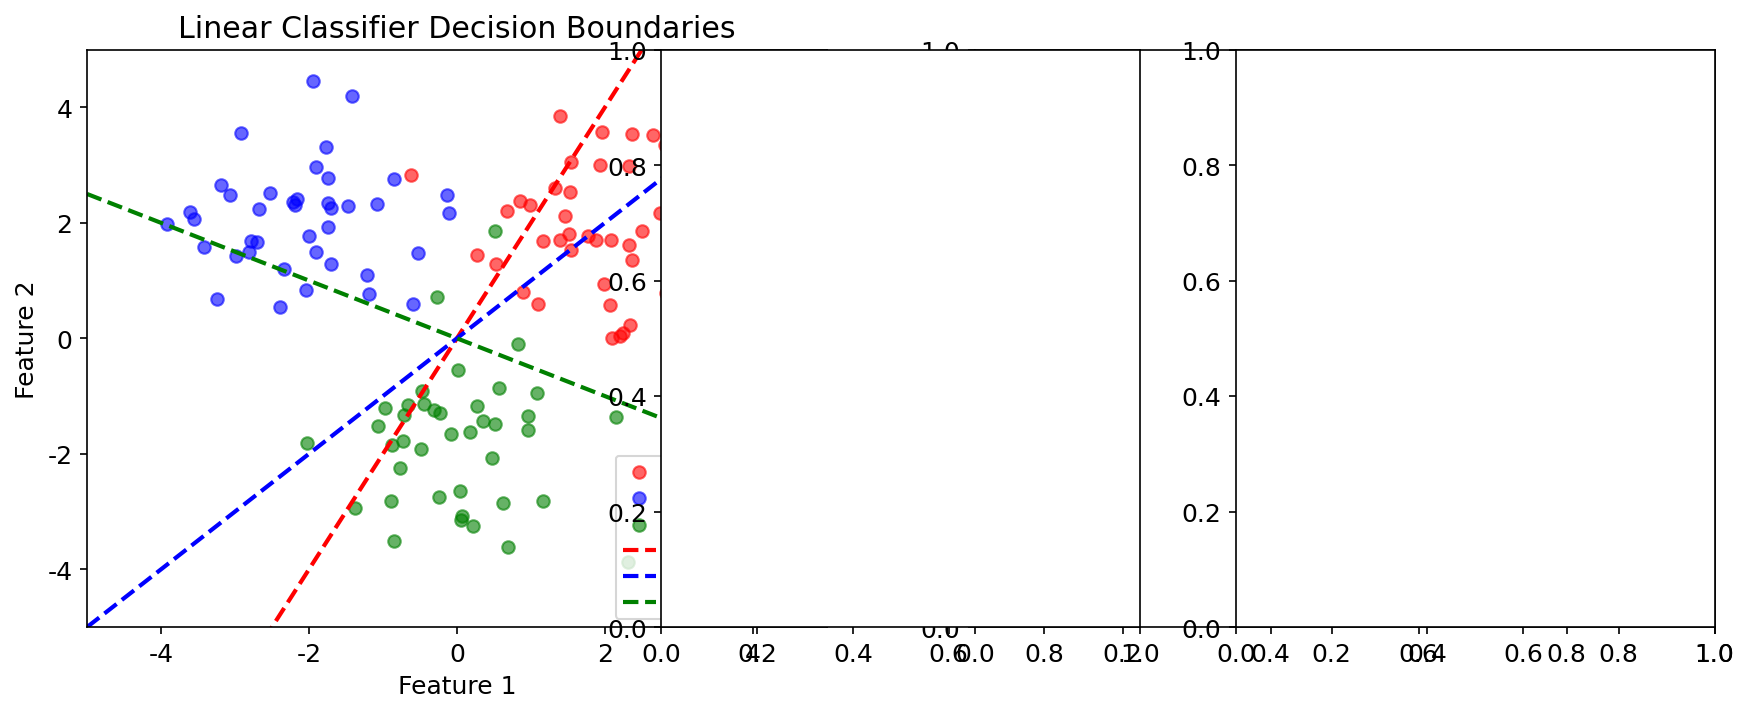

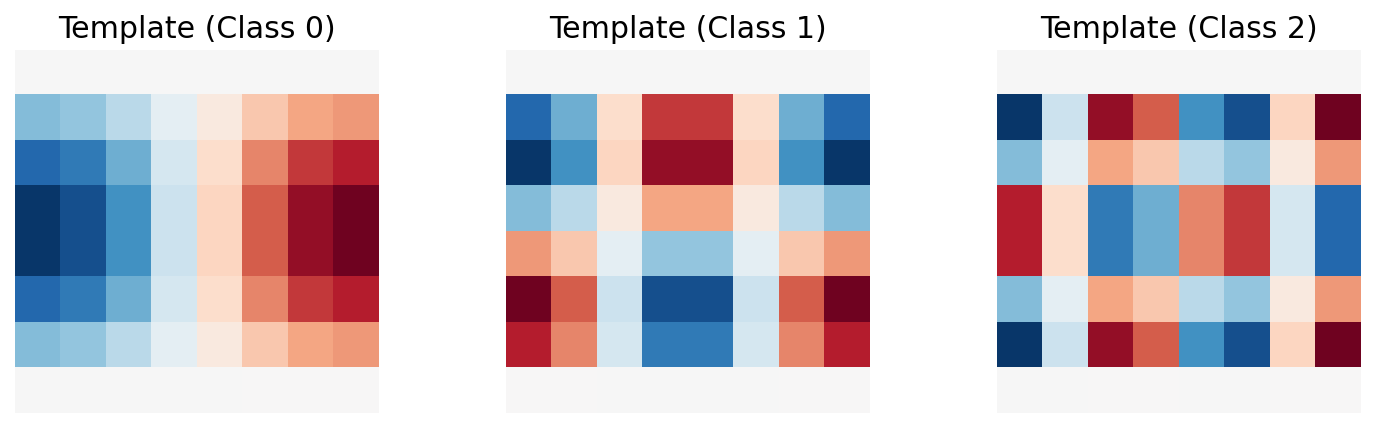

In [12]:
# Visualize linear classifier concept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D decision boundaries
ax = axes[0]
np.random.seed(42)
# Generate 3-class 2D data
centers = [[2, 2], [-2, 2], [0, -2]]
X_lin = np.vstack([np.random.randn(40, 2) + c for c in centers])
y_lin = np.hstack([np.full(40, i) for i in range(3)])

# Random weights for illustration
W_demo = np.array([[1, -0.5], [-1, 1], [0.5, 1]])
b_demo = np.array([0, 0, 0])

# Plot data
colors = ['red', 'blue', 'green']
for c in range(3):
    ax.scatter(X_lin[y_lin==c, 0], X_lin[y_lin==c, 1], c=colors[c], alpha=0.6, label=f'Class {c}')

# Plot decision boundaries
x_range = np.linspace(-5, 5, 100)
for c in range(3):
    # W[c] . x + b[c] = 0 => w1*x + w2*y + b = 0 => y = -(w1*x + b)/w2
    if W_demo[c, 1] != 0:
        y_boundary = -(W_demo[c, 0] * x_range + b_demo[c]) / W_demo[c, 1]
        ax.plot(x_range, y_boundary, '--', color=colors[c], linewidth=2, label=f'Boundary class {c}')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_title('Linear Classifier Decision Boundaries')
ax.legend(fontsize=8)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

# Right: Template interpretation
ax = axes[1]
# Simulate image templates (8x8 grayscale)
templates = np.random.randn(3, 8, 8)
for i in range(3):
    templates[i] = np.outer(np.sin(np.linspace(0, (i+1)*np.pi, 8)), np.cos(np.linspace(0, (i+1)*np.pi, 8)))
    
for i in range(3):
    ax = plt.subplot(1, 3, i+1) if i > 0 else axes[1]
    
# Use subplot approach
fig2, axes2 = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    im = axes2[i].imshow(templates[i], cmap='RdBu', vmin=-1, vmax=1)
    axes2[i].set_title(f'Template (Class {i})')
    axes2[i].axis('off')
plt.tight_layout()
plt.savefig('linear_classifier_concept.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as linear_classifier_concept.png")


## 4. SVM 损失函数（合页损失 Hinge Loss）

### 4.1 直觉理解

SVM 损失的核心思想：**正确类别的得分应该比其他类别的得分高出至少一个安全间隔 delta。**

**多类 SVM 损失 (Multiclass SVM / Weston-Watkins Hinge Loss):**

$$L_i = \sum_{j \neq y_i} \max(0, s_j - s_{y_i} + \Delta)$$

其中 $s_j = f(x_i, W)_j$ 是第 j 类的得分，$y_i$ 是正确类别。

**理解：**
- 如果正确类别得分比第 j 类高出至少 $Delta$，则该项为 0（无损失）
- 否则，损失等于差距的负值
- $Delta$ 通常设为 1.0（因为正则化会自动调节间隔）


### 4.2 手动计算 SVM 损失

**示例：** 3 个类别，得分为 $s = [3.2, 5.1, -1.7]$，正确类别 $y = 0$（第0类），$Delta = 1$

**计算各项：**
- 类别 1 ($j=1$)：$\max(0, 5.1 - 3.2 + 1) = \max(0, 2.9) = 2.9$
- 类别 2 ($j=2$)：$\max(0, -1.7 - 3.2 + 1) = \max(0, -3.9) = 0$

**总损失：** $L_i = 2.9 + 0 = 2.9$

**再算一个例子：** $s = [1.0, 1.0, 1.0]$，$y = 0$，$Delta = 1$
- 类别 1：$\max(0, 1.0 - 1.0 + 1) = 1.0$
- 类别 2：$\max(0, 1.0 - 1.0 + 1) = 1.0$
- $L_i = 1.0 + 1.0 = 2.0$

**注意：** 当所有得分相同时，SVM 损失等于 $\Delta \times (C-1)$


In [15]:
# SVM loss implementation
def svm_loss_naive(scores, y):
    """
    SVM loss (hinge loss), naive implementation
    Args:
        scores: (N, C) predicted scores
        y: (N,) true labels
    Returns:
        loss: scalar
    """
    N = scores.shape[0]
    C = scores.shape[1]
    delta = 1.0
    
    loss = 0.0
    for i in range(N):
        correct_score = scores[i, y[i]]
        for j in range(C):
            if j == y[i]:
                continue
            margin = scores[i, j] - correct_score + delta
            loss += max(0, margin)
    
    return loss / N

# Test with manual calculation
scores_test = np.array([[3.2, 5.1, -1.7]])
y_test = np.array([0])
loss = svm_loss_naive(scores_test, y_test)
print(f"SVM loss for s=[3.2, 5.1, -1.7], y=0: {loss:.4f}")
print(f"Expected: 2.9000")

scores_test2 = np.array([[1.0, 1.0, 1.0]])
loss2 = svm_loss_naive(scores_test2, y_test)
print(f"SVM loss for s=[1,1,1], y=0: {loss2:.4f}")
print(f"Expected: 2.0000")


SVM loss for s=[3.2, 5.1, -1.7], y=0: 2.9000
Expected: 2.9000
SVM loss for s=[1,1,1], y=0: 2.0000
Expected: 2.0000


### 4.3 SVM 损失的向量化实现

**手动推导向量化：**

对于样本 i，正确类别 $y_i$：

$$L_i = \sum_{j \neq y_i} \max(0, s_j - s_{y_i} + \Delta)$$

向量化步骤：
1. 提取正确类别得分：$s_{y_i} = \text{scores}[\text{range}(N), y]$ (shape: N,)
2. 计算所有 margin：$M = S - s_{y_i}[:, None] + \Delta$ (shape: N, C)
3. 将正确类别的 margin 设为 0
4. 应用 hinge：$M = \max(0, M)$
5. 求和并除以 N


In [17]:
# SVM loss vectorized
def svm_loss_vectorized(scores, y):
    """
    SVM loss, fully vectorized implementation
    """
    N = scores.shape[0]
    delta = 1.0
    
    # Get correct class scores: (N,)
    correct_scores = scores[np.arange(N), y]
    
    # Compute all margins: (N, C)
    margins = scores - correct_scores[:, None] + delta
    
    # Zero out correct class
    margins[np.arange(N), y] = 0
    
    # Apply hinge
    margins = np.maximum(0, margins)
    
    # Average loss
    loss = np.sum(margins) / N
    
    return loss

# Verify both implementations give same result
np.random.seed(42)
scores_big = np.random.randn(100, 10)
y_big = np.random.randint(0, 10, 100)

loss_naive = svm_loss_naive(scores_big, y_big)
loss_vec = svm_loss_vectorized(scores_big, y_big)
print(f"Naive loss:  {loss_naive:.6f}")
print(f"Vectorized:  {loss_vec:.6f}")
print(f"Difference:  {abs(loss_naive - loss_vec):.10f}")


Naive loss:  10.822969
Vectorized:  10.822969
Difference:  0.0000000000


### 4.4 SVM 损失的梯度推导

**对 $s_j$ 求导（当 $j \neq y_i$）：**

$$\frac{\partial L_i}{\partial s_j} = \begin{cases} 1 & \text{if } s_j - s_{y_i} + \Delta > 0 \\ 0 & \text{otherwise} \end{cases}$$

**对 $s_{y_i}$ 求导（正确类别）：**

$$\frac{\partial L_i}{\partial s_{y_i}} = -\sum_{j \neq y_i} \mathbb{1}(s_j - s_{y_i} + \Delta > 0)$$

即：正确类别得分的梯度等于违反间隔的类别数量的负值。

**手动计算梯度：** $s = [3.2, 5.1, -1.7]$, $y=0$, $\Delta=1$
- 类别 1：margin = 2.9 > 0, 梯度 = 1
- 类别 2：margin = -3.9 < 0, 梯度 = 0
- 正确类别梯度 = -(1) = -1
- 梯度向量 = [-1, 1, 0]


In [19]:
# SVM gradient implementation
def svm_loss_grad(scores, y):
    """
    Compute SVM loss and gradient w.r.t. scores
    Returns:
        loss: scalar
        dscores: (N, C) gradient w.r.t. scores
    """
    N = scores.shape[0]
    delta = 1.0
    
    correct_scores = scores[np.arange(N), y]
    margins = scores - correct_scores[:, None] + delta
    margins[np.arange(N), y] = 0
    margins = np.maximum(0, margins)
    
    loss = np.sum(margins) / N
    
    # Gradient
    dscores = (margins > 0).astype(float)
    # Count violations per sample for correct class
    dscores[np.arange(N), y] = -np.sum(dscores, axis=1)
    dscores /= N
    
    return loss, dscores

# Verify with manual example
scores_manual = np.array([[3.2, 5.1, -1.7]])
y_manual = np.array([0])
loss, grad = svm_loss_grad(scores_manual, y_manual)
print(f"Loss: {loss:.4f}")
print(f"Gradient: {grad}")
print(f"Expected gradient: [-1, 1, 0] (divided by N=1)")


Loss: 2.9000
Gradient: [[-1.  1.  0.]]
Expected gradient: [-1, 1, 0] (divided by N=1)


## 5. Softmax 损失函数（交叉熵损失）

### 5.1 直觉理解

Softmax 分类器将得分转化为概率分布，然后使用交叉熵损失。

**Softmax 函数：**

$$P(y=j | x_i) = \frac{e^{s_j}}{\sum_k e^{s_k}}$$

**交叉熵损失：**

$$L_i = -\log P(y=y_i | x_i) = -s_{y_i} + \log \sum_k e^{s_k}$$

**理解：**
- Softmax 将得分压缩为 [0,1] 之间的概率，且总和为 1
- 交叉熵衡量预测概率分布与真实分布之间的差异
- 当正确类别概率接近 1 时，损失接近 0
- 当正确类别概率接近 0 时，损失趋近无穷


### 5.2 手动计算 Softmax 损失

**示例：** $s = [3.2, 5.1, -1.7]$, $y = 0$（正确类别是第0类）

**步骤 1：计算 exp**
- $e^{3.2} \approx 24.53$
- $e^{5.1} \approx 164.02$
- $e^{-1.7} \approx 0.18$

**步骤 2：求和**
- $\sum = 24.53 + 164.02 + 0.18 = 188.73$

**步骤 3：计算正确类别概率**
- $P(y=0) = 24.53 / 188.73 \approx 0.130$

**步骤 4：计算损失**
- $L = -\log(0.130) \approx 2.04$

**理解：** 虽然第0类得分(3.2)不低，但第1类得分(5.1)更高，所以正确类别概率只有 13%，损失较大。


In [22]:
# Softmax loss implementation
def softmax_loss(scores, y):
    """
    Compute Softmax (cross-entropy) loss and gradient
    Args:
        scores: (N, C) raw scores
        y: (N,) true labels
    Returns:
        loss: scalar
        dscores: (N, C) gradient w.r.t. scores
    """
    N = scores.shape[0]
    
    # Numerical stability: subtract max
    shifted = scores - np.max(scores, axis=1, keepdims=True)
    
    # Compute softmax probabilities
    exp_scores = np.exp(shifted)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    
    # Loss: -log(prob of correct class)
    correct_logprobs = -np.log(probs[np.arange(N), y])
    loss = np.sum(correct_logprobs) / N
    
    # Gradient: (probs - one_hot) / N
    dscores = probs.copy()
    dscores[np.arange(N), y] -= 1
    dscores /= N
    
    return loss, dscores

# Test with manual example
scores_manual = np.array([[3.2, 5.1, -1.7]])
y_manual = np.array([0])
loss, grad = softmax_loss(scores_manual, y_manual)
print(f"Softmax loss: {loss:.4f}")
print(f"Expected: ~2.04")
print(f"Gradient: {grad}")

# Show probabilities
shifted = scores_manual - np.max(scores_manual)
probs = np.exp(shifted) / np.sum(np.exp(shifted))
print(f"Probabilities: {probs[0]}")
print(f"Correct class probability: {probs[0, 0]:.4f}")


Softmax loss: 2.0404
Expected: ~2.04
Gradient: [[-0.87001746  0.86904954  0.00096793]]
Probabilities: [0.12998254 0.86904954 0.00096793]
Correct class probability: 0.1300


### 5.3 数值稳定性问题

Softmax 计算中 $e^{s_j}$ 当 $s_j$ 很大时会溢出。

**解决方案：** 减去最大值

$$P(y=j) = \frac{e^{s_j - \max(s)}}{\sum_k e^{s_k - \max(s)}}$$

**为什么安全？** $e^{s_j}$ 和 $e^{s_j - \max(s)}$ 在归一化后结果相同，但后者不会溢出。

**手动验证：**
- 原始：$s = [1000, 1001, 1002]$，$e^{1000}$ = 溢出
- 平移后：$s' = [-2, -1, 0]$，$e^{-2} \approx 0.135$，$e^{-1} \approx 0.368$，$e^0 = 1$
- 概率：$[0.090, 0.245, 0.665]$，无溢出


In [24]:
# Demonstrate numerical stability
# Without stability fix
big_scores = np.array([[1000, 1001, 1002]])
try:
    exp_big = np.exp(big_scores)
    print(f"exp(1000) = {exp_big[0,0]}")
except:
    print("Overflow error!")

# With stability fix
shifted = big_scores - np.max(big_scores)
exp_shifted = np.exp(shifted)
probs = exp_shifted / np.sum(exp_shifted)
print(f"Stable softmax probabilities: {probs[0]}")
print(f"Sum = {np.sum(probs):.6f}")

# Compare with scipy-like implementation
print("\n--- Probability comparison ---")
small_scores = np.array([[1.0, 2.0, 3.0]])
shifted = small_scores - np.max(small_scores)
probs = np.exp(shifted) / np.sum(np.exp(shifted))
print(f"Scores: {small_scores[0]}")
print(f"Probabilities: {probs[0]}")
print(f"Log of correct class (y=2): {-np.log(probs[0,2]):.4f}")


exp(1000) = inf
Stable softmax probabilities: [0.09003057 0.24472847 0.66524096]
Sum = 1.000000

--- Probability comparison ---
Scores: [1. 2. 3.]
Probabilities: [0.09003057 0.24472847 0.66524096]
Log of correct class (y=2): 0.4076


## 6. SVM 与 Softmax 对比

| 特性 | SVM (Hinge Loss) | Softmax (Cross-Entropy) |
|------|------------------|------------------------|
| 损失函数 | $\max(0, s_j - s_{y_i} + 1)$ | $-\log P(y=y_i)$ |
| 输出解释 | 类别得分（无界） | 概率分布（0到1，和为1） |
| 满足间隔时 | 损失=0，梯度=0 | 损失>0，梯度持续优化 |
| 对错误置信度 | 有上限（hinge） | 无上限（指数惩罚） |
| 可解释性 | 较弱 | 较强（概率） |

**关键区别：** 当 SVM 的间隔满足时，不再优化；Softmax 会持续优化正确类别的概率接近 1。


Visualization saved as svm_vs_softmax.png


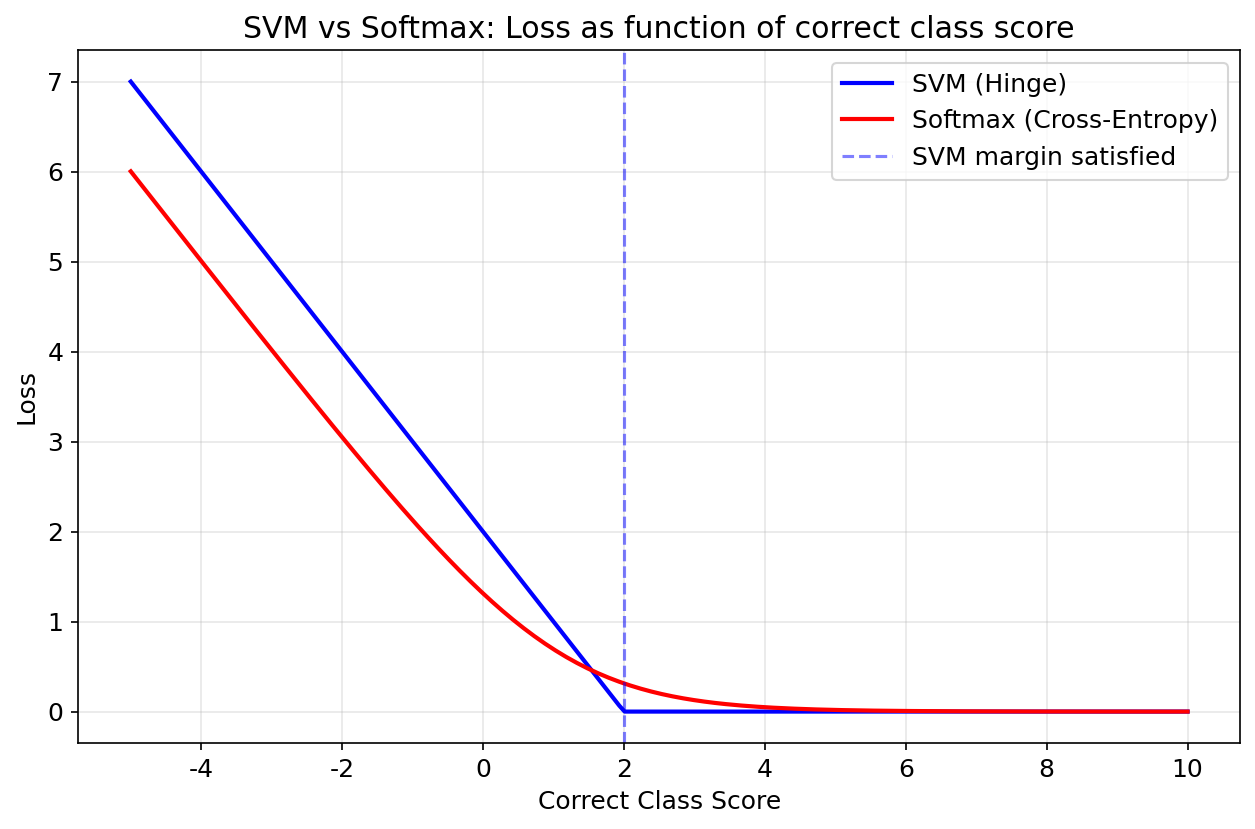

In [26]:
# Compare SVM and Softmax loss behavior
# Vary correct class score while keeping others fixed
correct_scores_range = np.linspace(-5, 10, 200)
other_score = 1.0  # Fixed other class score
delta = 1.0

svm_losses = []
softmax_losses = []

for cs in correct_scores_range:
    # SVM
    svm_loss = max(0, other_score - cs + delta)
    svm_losses.append(svm_loss)
    
    # Softmax
    scores = np.array([cs, other_score])
    scores_shifted = scores - np.max(scores)
    probs = np.exp(scores_shifted) / np.sum(np.exp(scores_shifted)
)
    sm_loss = -np.log(probs[0])
    softmax_losses.append(sm_loss)

plt.figure(figsize=(10, 6))
plt.plot(correct_scores_range, svm_losses, 'b-', linewidth=2, label='SVM (Hinge)')
plt.plot(correct_scores_range, softmax_losses, 'r-', linewidth=2, label='Softmax (Cross-Entropy)')
plt.axvline(x=other_score + delta, color='b', linestyle='--', alpha=0.5, label='SVM margin satisfied')
plt.xlabel('Correct Class Score')
plt.ylabel('Loss')
plt.title('SVM vs Softmax: Loss as function of correct class score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('svm_vs_softmax.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as svm_vs_softmax.png")


## 7. 正则化

### 7.1 为什么需要正则化

**问题：** 假设 W 是一个使损失为 0 的解，那么 2W 也会使损失为 0（间隔翻倍）。权重可以无限增大。

**L2 正则化：** 在损失中添加惩罚项

$$L = \frac{1}{N} \sum_i L_i + \lambda R(W)$$

$$R(W) = \sum_{k,l} W_{k,l}^2$$

**效果：**
- 鼓励小的、分散的权重
- 防止过拟合
- $lambda$ 是超参数，控制正则化强度

### 7.2 正则化对 SVM 梯度的影响

加入 L2 正则化后，SVM 的梯度变为：

$$\frac{\partial L}{\partial W} = \frac{1}{N} \cdot (\text{data gradient}) + 2\lambda W$$


In [28]:
# L2 Regularization implementation
def l2_regularization(W, reg_strength):
    """
    L2 regularization loss and gradient
    """
    loss = reg_strength * np.sum(W * W)
    grad = 2 * reg_strength * W
    return loss, grad

# Complete SVM loss with regularization
def svm_loss_complete(X, y, W, reg):
    """
    Full SVM loss with L2 regularization
    Args:
        X: (N, D) input data
        y: (N,) labels
        W: (D, C) weights
        reg: regularization strength
    """
    N = X.shape[0]
    scores = X @ W  # (N, C)
    
    # Data loss
    correct_scores = scores[np.arange(N), y]
    margins = scores - correct_scores[:, None] + 1.0
    margins[np.arange(N), y] = 0
    margins = np.maximum(0, margins)
    data_loss = np.sum(margins) / N
    
    # Regularization
    reg_loss = reg * np.sum(W * W)
    
    # Gradients
    dscores = (margins > 0).astype(float)
    dscores[np.arange(N), y] = -np.sum(dscores, axis=1)
    dscores /= N
    dW = X.T @ dscores + 2 * reg * W
    
    return data_loss + reg_loss, dW

# Test
np.random.seed(42)
D, C, N = 10, 3, 50
X_test = np.random.randn(N, D)
y_test = np.random.randint(0, C, N)
W_test = np.random.randn(D, C) * 0.001

loss, grad = svm_loss_complete(X_test, y_test, W_test, reg=0.1)
print(f"SVM loss (with reg): {loss:.4f}")
print(f"Gradient shape: {grad.shape}")


SVM loss (with reg): 1.9992
Gradient shape: (10, 3)


In [29]:
# Softmax loss with regularization
def softmax_loss_complete(X, y, W, reg):
    """
    Full Softmax loss with L2 regularization
    """
    N = X.shape[0]
    scores = X @ W  # (N, C)
    
    # Softmax probabilities
    shifted = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    
    # Data loss
    correct_logprobs = -np.log(probs[np.arange(N), y])
    data_loss = np.sum(correct_logprobs) / N
    
    # Regularization
    reg_loss = reg * np.sum(W * W)
    
    # Gradients
    dscores = probs.copy()
    dscores[np.arange(N), y] -= 1
    dscores /= N
    dW = X.T @ dscores + 2 * reg * W
    
    return data_loss + reg_loss, dW

# Test
loss, grad = softmax_loss_complete(X_test, y_test, W_test, reg=0.1)
print(f"Softmax loss (with reg): {loss:.4f}")
print(f"Gradient shape: {grad.shape}")


Softmax loss (with reg): 1.0984
Gradient shape: (10, 3)


## 8. 梯度检验

**数值梯度检验** 是验证解析梯度的标准方法：

$$\frac{\partial f}{\partial x} \approx \frac{f(x + h) - f(x - h)}{2h}$$

通常 $h = 10^{-5}$，比较数值梯度和解析梯度的相对误差。


In [31]:
# Numerical gradient checking
def numerical_grad(f, x, h=1e-5):
    """
    Numerical gradient using central differences
    """
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        old_val = x[idx]
        x[idx] = old_val + h
        f_plus = f(x)
        x[idx] = old_val - h
        f_minus = f(x)
        x[idx] = old_val
        grad[idx] = (f_plus - f_minus) / (2 * h)
        it.iternext()
    return grad

# Check SVM gradient
np.random.seed(42)
D, C, N = 5, 3, 10
X_check = np.random.randn(N, D)
y_check = np.random.randint(0, C, N)
W_check = np.random.randn(D, C) * 0.01

# Analytical gradient
loss_analytic, grad_analytic = svm_loss_complete(X_check, y_check, W_check, reg=0.1)

# Numerical gradient
f = lambda W: svm_loss_complete(X_check, y_check, W, reg=0.1)[0]
grad_numeric = numerical_grad(f, W_check.copy())

# Compare
print("=== SVM Gradient Check ===")
print(f"Analytical grad norm: {np.linalg.norm(grad_analytic):.6f}")
print(f"Numerical grad norm:  {np.linalg.norm(grad_numeric):.6f}")
diff = np.linalg.norm(grad_analytic - grad_numeric) / max(np.linalg.norm(grad_analytic), np.linalg.norm(grad_numeric))
print(f"Relative difference:   {diff:.2e}")
if diff < 1e-6:
    print("PASS: Gradients match!")
else:
    print("FAIL: Check gradient computation")


=== SVM Gradient Check ===
Analytical grad norm: 1.280474
Numerical grad norm:  1.280474
Relative difference:   4.41e-11
PASS: Gradients match!


In [32]:
# Check Softmax gradient
loss_analytic, grad_analytic = softmax_loss_complete(X_check, y_check, W_check, reg=0.1)

f = lambda W: softmax_loss_complete(X_check, y_check, W, reg=0.1)[0]
grad_numeric = numerical_grad(f, W_check.copy())

print("=== Softmax Gradient Check ===")
print(f"Analytical grad norm: {np.linalg.norm(grad_analytic):.6f}")
print(f"Numerical grad norm:  {np.linalg.norm(grad_numeric):.6f}")
diff = np.linalg.norm(grad_analytic - grad_numeric) / max(np.linalg.norm(grad_analytic), np.linalg.norm(grad_numeric))
print(f"Relative difference:   {diff:.2e}")
if diff < 1e-6:
    print("PASS: Gradients match!")
else:
    print("FAIL: Check gradient computation")


=== Softmax Gradient Check ===
Analytical grad norm: 0.423749
Numerical grad norm:  0.423749
Relative difference:   9.35e-11
PASS: Gradients match!


## 9. 完整的线性分类器训练

现在我们将所有组件组合成一个完整的训练流程：

1. 初始化权重
2. 前向传播计算得分
3. 计算损失和梯度
4. 用梯度下降更新权重
5. 重复

**超参数：** 学习率 (learning rate)、正则化强度 (regularization)、训练轮数 (epochs)


In [34]:
# Complete Linear Classifier class
class LinearClassifier:
    """Linear classifier with SVM or Softmax loss"""
    
    def __init__(self, D, C, loss_type='svm', reg=0.1, lr=0.1):
        self.W = np.random.randn(D, C) * 0.001
        self.loss_type = loss_type
        self.reg = reg
        self.lr = lr
        self.loss_history = []
        
    def train_step(self, X, y):
        N = X.shape[0]
        scores = X @ self.W  # (N, C)
        
        if self.loss_type == 'svm':
            # SVM loss
            correct_scores = scores[np.arange(N), y]
            margins = scores - correct_scores[:, None] + 1.0
            margins[np.arange(N), y] = 0
            margins = np.maximum(0, margins)
            data_loss = np.sum(margins) / N
            
            dscores = (margins > 0).astype(float)
            dscores[np.arange(N), y] = -np.sum(dscores, axis=1)
            dscores /= N
        else:
            # Softmax loss
            shifted = scores - np.max(scores, axis=1, keepdims=True)
            exp_scores = np.exp(shifted)
            probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            data_loss = np.sum(-np.log(probs[np.arange(N), y])) / N
            
            dscores = probs.copy()
            dscores[np.arange(N), y] -= 1
            dscores /= N
        
        reg_loss = self.reg * np.sum(self.W * self.W)
        loss = data_loss + reg_loss
        
        dW = X.T @ dscores + 2 * self.reg * self.W
        
        # Gradient descent update
        self.W -= self.lr * dW
        
        self.loss_history.append(loss)
        return loss
    
    def predict(self, X):
        scores = X @ self.W
        return np.argmax(scores, axis=1)
    
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

print("LinearClassifier class defined!")


LinearClassifier class defined!


In [35]:
# Generate synthetic classification dataset
np.random.seed(42)
n_samples = 200
n_classes = 3
n_features = 2

# Generate data with simple structure
centers = [[1, 1], [-1, 1], [0, -1]]
X_train = np.vstack([np.random.randn(n_samples//n_classes, n_features) * 0.5 + c for c in centers])
y_train = np.hstack([np.full(n_samples//n_classes, i) for i in range(n_classes)])

X_test = np.vstack([np.random.randn(n_samples//n_classes, n_features) * 0.5 + c for c in centers])
y_test = np.hstack([np.full(n_samples//n_classes, i) for i in range(n_classes)])

# Add bias term
X_train_bias = np.hstack([X_train, np.ones((n_samples, 1))])
X_test_bias = np.hstack([X_test, np.ones((n_samples, 1))])

print(f"Training data: {X_train_bias.shape}")
print(f"Test data: {X_test_bias.shape}")
print(f"Classes: {n_classes}")


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 198 and the array at index 1 has size 200

In [36]:
# Train SVM and Softmax classifiers
svm_clf = LinearClassifier(D=3, C=3, loss_type='svm', reg=0.01, lr=0.5)
softmax_clf = LinearClassifier(D=3, C=3, loss_type='softmax', reg=0.01, lr=0.5)

n_epochs = 200
for epoch in range(n_epochs):
    svm_loss = svm_clf.train_step(X_train_bias, y_train)
    softmax_loss = softmax_clf.train_step(X_train_bias, y_train)

print(f"SVM:     Final loss={svm_clf.loss_history[-1]:.4f}, Train acc={svm_clf.accuracy(X_train_bias, y_train):.4f}, Test acc={svm_clf.accuracy(X_test_bias, y_test):.4f}")
print(f"Softmax: Final loss={softmax_clf.loss_history[-1]:.4f}, Train acc={softmax_clf.accuracy(X_train_bias, y_train):.4f}, Test acc={softmax_clf.accuracy(X_test_bias, y_test):.4f}")


NameError: name 'X_train_bias' is not defined

## 10. 实验观察

### 实验 1：损失曲线可视化


In [38]:
# Plot training loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(svm_clf.loss_history, 'b-', linewidth=1.5, label='SVM')
axes[0].plot(softmax_clf.loss_history, 'r-', linewidth=1.5, label='Softmax')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
svm_acc = np.mean([svm_clf.accuracy(X_train_bias, y_train)])
softmax_acc = np.mean([softmax_clf.accuracy(X_train_bias, y_train)])

axes[1].bar(['SVM', 'Softmax'], [svm_acc, softmax_acc], color=['blue', 'red'], alpha=0.7)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy Comparison')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate([svm_acc, softmax_acc]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=14)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as training_curves.png")


NameError: name 'X_train_bias' is not defined

### 实验 2：决策边界可视化


Visualization saved as decision_boundaries.png


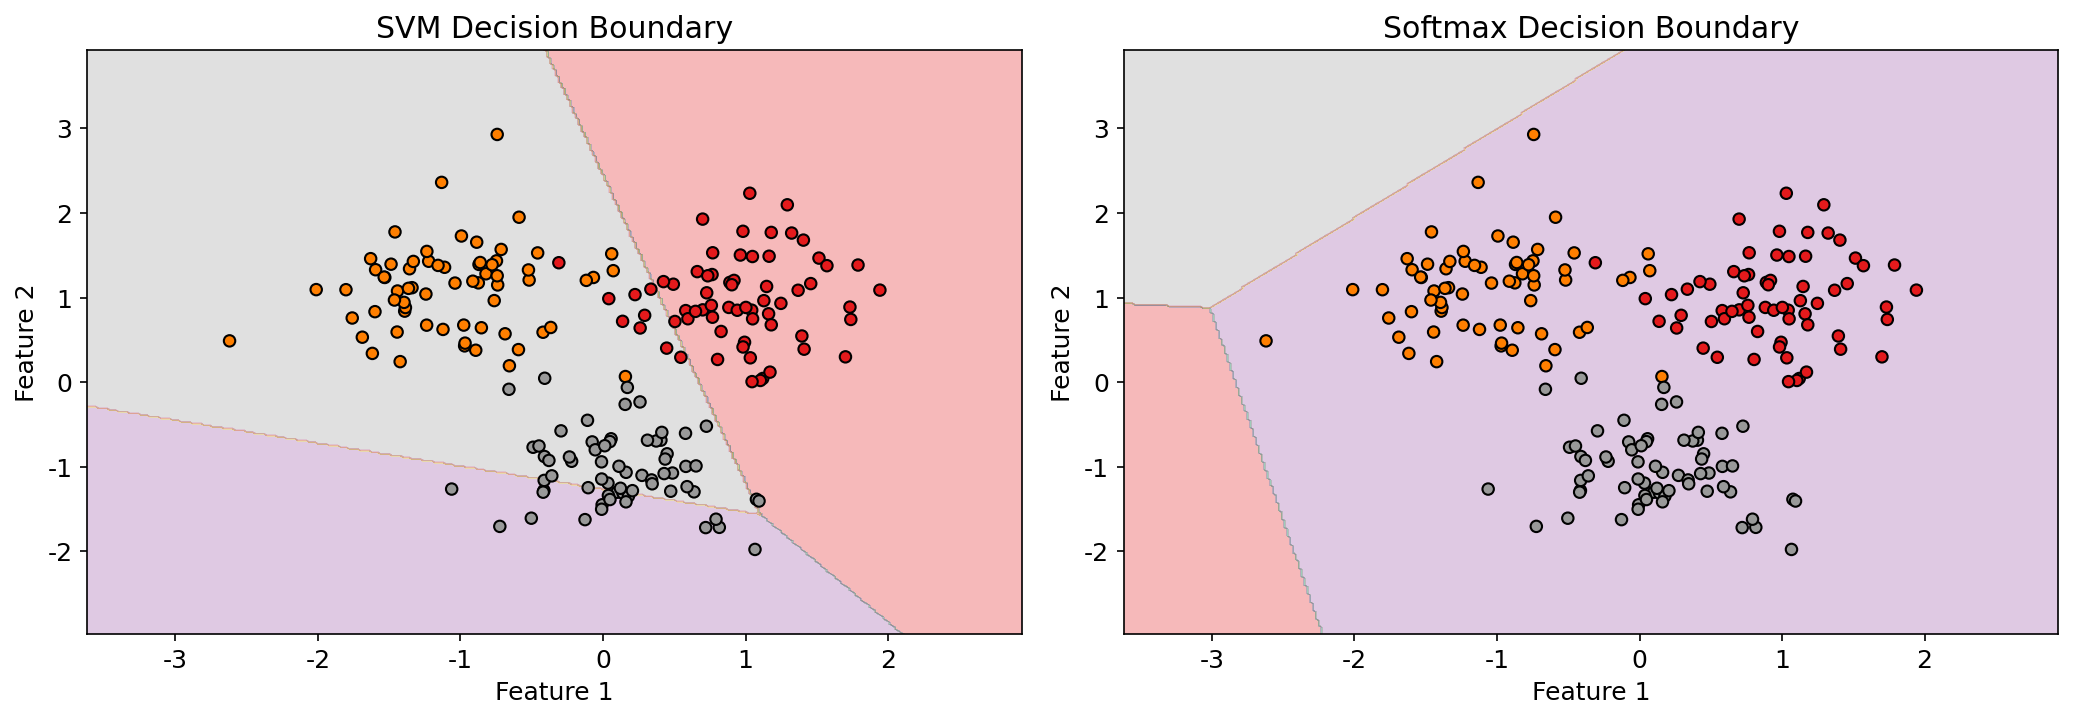

In [40]:
# Plot decision boundaries
def plot_decision_boundary(clf, X, y, ax, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel(), np.ones(xx.ravel().shape)].T if False else np.c_[xx.ravel(), yy.ravel(), np.ones(xx.ravel().shape)])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolors='black', s=30)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_clf, X_train, y_train, axes[0], 'SVM Decision Boundary')
plot_decision_boundary(softmax_clf, X_train, y_train, axes[1], 'Softmax Decision Boundary')
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as decision_boundaries.png")


### 实验 3：学习率的影响


In [42]:
# Experiment with different learning rates
learning_rates = [0.01, 0.1, 0.5, 1.0, 5.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in learning_rates:
    clf = LinearClassifier(D=3, C=3, loss_type='svm', reg=0.01, lr=lr)
    losses = []
    for epoch in range(200):
        loss = clf.train_step(X_train_bias, y_train)
        losses.append(loss)
    axes[0].plot(losses, label=f'lr={lr}', linewidth=1.5)
    
    clf = LinearClassifier(D=3, C=3, loss_type='softmax', reg=0.01, lr=lr)
    losses = []
    for epoch in range(200):
        loss = clf.train_step(X_train_bias, y_train)
        losses.append(loss)
    axes[1].plot(losses, label=f'lr={lr}', linewidth=1.5)

axes[0].set_title('SVM: Effect of Learning Rate')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Softmax: Effect of Learning Rate')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_rate_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as learning_rate_effect.png")


NameError: name 'X_train_bias' is not defined

### 实验 4：正则化强度的影响


In [44]:
# Experiment with different regularization strengths
reg_strengths = [0, 0.001, 0.01, 0.1, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_accs_svm = []
test_accs_svm = []
train_accs_sm = []
test_accs_sm = []

for reg in reg_strengths:
    # SVM
    clf = LinearClassifier(D=3, C=3, loss_type='svm', reg=reg, lr=0.5)
    for _ in range(200):
        clf.train_step(X_train_bias, y_train)
    train_accs_svm.append(clf.accuracy(X_train_bias, y_train))
    test_accs_svm.append(clf.accuracy(X_test_bias, y_test))
    
    # Softmax
    clf = LinearClassifier(D=3, C=3, loss_type='softmax', reg=reg, lr=0.5)
    for _ in range(200):
        clf.train_step(X_train_bias, y_train)
    train_accs_sm.append(clf.accuracy(X_train_bias, y_train))
    test_accs_sm.append(clf.accuracy(X_test_bias, y_test))

x_pos = np.arange(len(reg_strengths))
width = 0.35

axes[0].bar(x_pos - width/2, train_accs_svm, width, label='Train', color='blue', alpha=0.7)
axes[0].bar(x_pos + width/2, test_accs_svm, width, label='Test', color='red', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(r) for r in reg_strengths])
axes[0].set_xlabel('Regularization Strength')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('SVM: Effect of Regularization')
axes[0].legend()

axes[1].bar(x_pos - width/2, train_accs_sm, width, label='Train', color='blue', alpha=0.7)
axes[1].bar(x_pos + width/2, test_accs_sm, width, label='Test', color='red', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([str(r) for r in reg_strengths])
axes[1].set_xlabel('Regularization Strength')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Softmax: Effect of Regularization')
axes[1].legend()

plt.tight_layout()
plt.savefig('regularization_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as regularization_effect.png")


NameError: name 'X_train_bias' is not defined

## 11. 实验结果分析

### 关键观察

1. **损失收敛**：SVM 损失在满足间隔后快速下降到 0，Softmax 损失持续优化但下降较慢。

2. **决策边界**：线性分类器只能学习线性决策边界，对于复杂分布效果有限。

3. **学习率影响**：
   - 学习率太小：收敛慢
   - 学习率适中：快速稳定收敛
   - 学习率太大：震荡甚至发散

4. **正则化影响**：
   - 正则化太弱：可能过拟合（训练准确率高，测试准确率低）
   - 正则化太强：欠拟合（两者都低）
   - 需要找到平衡点

### 线性分类器的局限性

线性分类器假设数据是**线性可分**的，但现实中的数据通常不是：
- **XOR 问题**：无法用线性边界分开
- **同心圆数据**：需要非线性边界
- **图像数据**：3072维空间中几乎不可能线性可分

**解决方案：** 后续课程将引入神经网络，通过隐藏层和非线性激活函数来学习复杂的决策边界。


## 12. 作业

### 作业 1：实现 L1 正则化的线性分类器

将 L2 正则化替换为 L1 正则化：$R(W) = \sum |W_{k,l}|$

**要求：**
1. 实现 L1 正则化的损失和梯度
2. 对比 L1 和 L2 正则化对权重分布的影响
3. 可视化两种正则化下的权重直方图

**提示：** L1 正则化的梯度是 $\text{sign}(W)$

### 作业 2：比较不同数据分布下的分类效果

使用以下数据分布测试线性分类器：
1. 线性可分数据
2. XOR 数据
3. 同心圆数据

**要求：**
1. 生成三种数据集
2. 训练 SVM 和 Softmax 分类器
3. 可视化决策边界
4. 分析为什么线性分类器在某些数据上失败

### 作业 3：实现 mini-batch 训练

当前实现使用全部训练数据进行每次更新（Batch Gradient Descent）。

**要求：**
1. 实现 mini-batch 训练（每次使用 32 个样本）
2. 对比不同 batch size (1, 16, 32, 64, 全部) 的收敛速度
3. 分析 mini-batch 对训练稳定性和速度的影响

**提示：** 使用 np.random.choice 随机采样


## 13. 参考文献

1. **CS231n: Convolutional Neural Networks for Visual Recognition**, Stanford University
   - Lecture 2: Image Classification pipeline
   - https://cs231n.github.io/classification/

2. **Weston, J. & Watkins, C. (1999)**. Support Vector Machines for Multi-Class Pattern Recognition. ESANN.

3. **Bishop, C. M. (2006)**. Pattern Recognition and Machine Learning. Springer. Chapter 4: Linear Models for Classification.

4. **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. Deep Learning. MIT Press. Chapter 5: Machine Learning Basics.

5. **Hastie, T., Tibshirani, R., & Friedman, J. (2009)**. The Elements of Statistical Learning. Springer. Chapter 4: Linear Methods for Classification.

6. **Crammer, K. & Singer, Y. (2001)**. On the Algorithmic Implementation of Multiclass Kernel-based Vector Machines. JMLR.

---

**本 notebook 总结：**
- 图像分类是计算机视觉的核心任务
- k-NN 简单但不适合图像分类（维度灾难、距离度量不匹配）
- 线性分类器：$f(x) = Wx + b$，参数化模型
- SVM 损失：合页损失，关注间隔
- Softmax 损失：交叉熵，输出概率
- 正则化防止过拟合
- 梯度检验验证梯度计算正确性


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): SVM 与 Softmax 线性分类器从零实现
  - 仓库地址: https://github.com/jariasf/CS231n

- **[bingcheng1998/CS231n-2020-spring-assignment-solution](https://github.com/bingcheng1998/CS231n-2020-spring-assignment-solution)** (146 stars): 2020春季作业解答，含线性分类器
  - 仓库地址: https://github.com/bingcheng1998/CS231n-2020-spring-assignment-solution

- **[madalinabuzau/cs231n-convolutional-neural-networks-solutions](https://github.com/madalinabuzau/cs231n-convolutional-neural-networks-solutions)** (113 stars): 2017版 TF+PyTorch 双框架解答
  - 仓库地址: https://github.com/madalinabuzau/cs231n-convolutional-neural-networks-solutions


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

